In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense,Input
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

import random

In [ ]:
import zipfile
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("emotionDataset")
print("Extraction complete.")





In [ ]:

# Image dimensions and batch size
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    directory='emotionDataset/data/train',
    color_mode='grayscale',
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # Resize images to 48x48
    batch_size=BATCH_SIZE,  # Process 32 images at a time
    class_mode='categorical',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    directory="emotionDataset/data/test",
    color_mode="grayscale",
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Image batch shape: (32, 48, 48, 1)
Random index: 3
Image shape: (48, 48, 1)
Image min/max values: 0.03504362 0.876741
Label: Happy


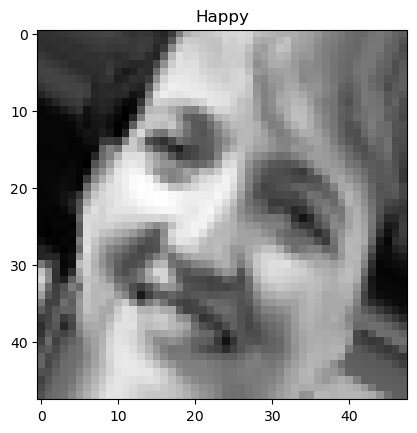

In [33]:
# Class labels
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


# Fetch a batch of images and labels
img, label = train_generator.__next__()
print("Image batch shape:", img.shape)  # Should be (batch_size, height, width, 1)

# Select a random image from the batch
i = random.randint(0, (img.shape[0])-1)
print("Random index:", i)
image = img[i]
print("Image shape:", image.shape)  # Should be (height, width, 1)
print("Image min/max values:", image.min(), image.max())  # Should be in [0, 1]

# Get the class label
label_index = label[i].argmax()  # Get the class index
label_name = class_labels[label_index]  # Map index to class name
print("Label:", label_name)

# Plot the image
plt.imshow(image.squeeze(), cmap='gray')  # Remove the last dimension for grayscale images
plt.title(label_name)  # Set the title to the class name
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Create the model
model = Sequential()
model.add(Input(shape=(48, 48, 1)))
# Add layers
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(7, activation='softmax'))  # Replace 7 with the number of classes

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = test_generator.samples // test_generator.batch_size

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=50 # Set the number of training epochs
)

# Print model summary
print(model.summary())
model.save("final_emotion-detection-model.keras")

In [ ]:
from tensorflow.keras.models import load_model
from sklearn import metrics  # Import the metrics module
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load the trained model
my_model = load_model('final_emotion-detection-model.keras')

# Generate a batch of test images and labels
test_img, test_lbl = test_generator.__next__()

# Make predictions
predictions = my_model.predict(test_img)
predictions = np.argmax(predictions, axis=1)
test_labels = np.argmax(test_lbl, axis=1)

# Calculate accuracy
accuracy = metrics.accuracy_score(test_labels, predictions)
print("Accuracy = ", accuracy)

# Confusion Matrix
cm = confusion_matrix(test_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Class labels
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Visualize a random test image
n = random.randint(0, test_img.shape[0] - 1)
image = test_img[n]
orig_labl = class_labels[test_labels[n]]
pred_labl = class_labels[predictions[n]]

plt.imshow(image[:,:,0], cmap='gray')
plt.title(f"Original label: {orig_labl}\nPredicted label: {pred_labl}")
plt.show()